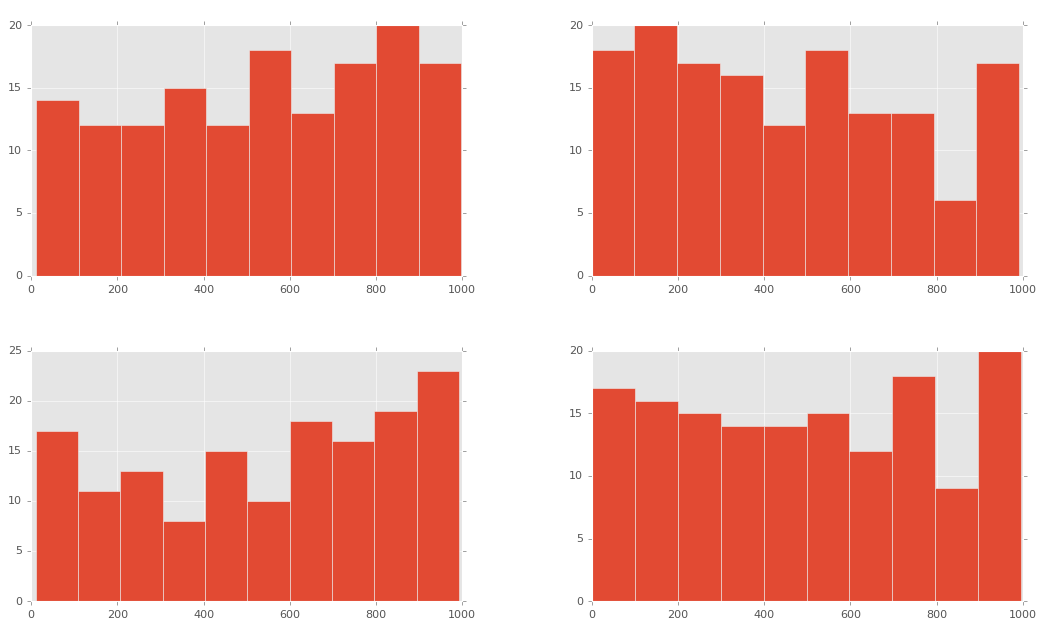

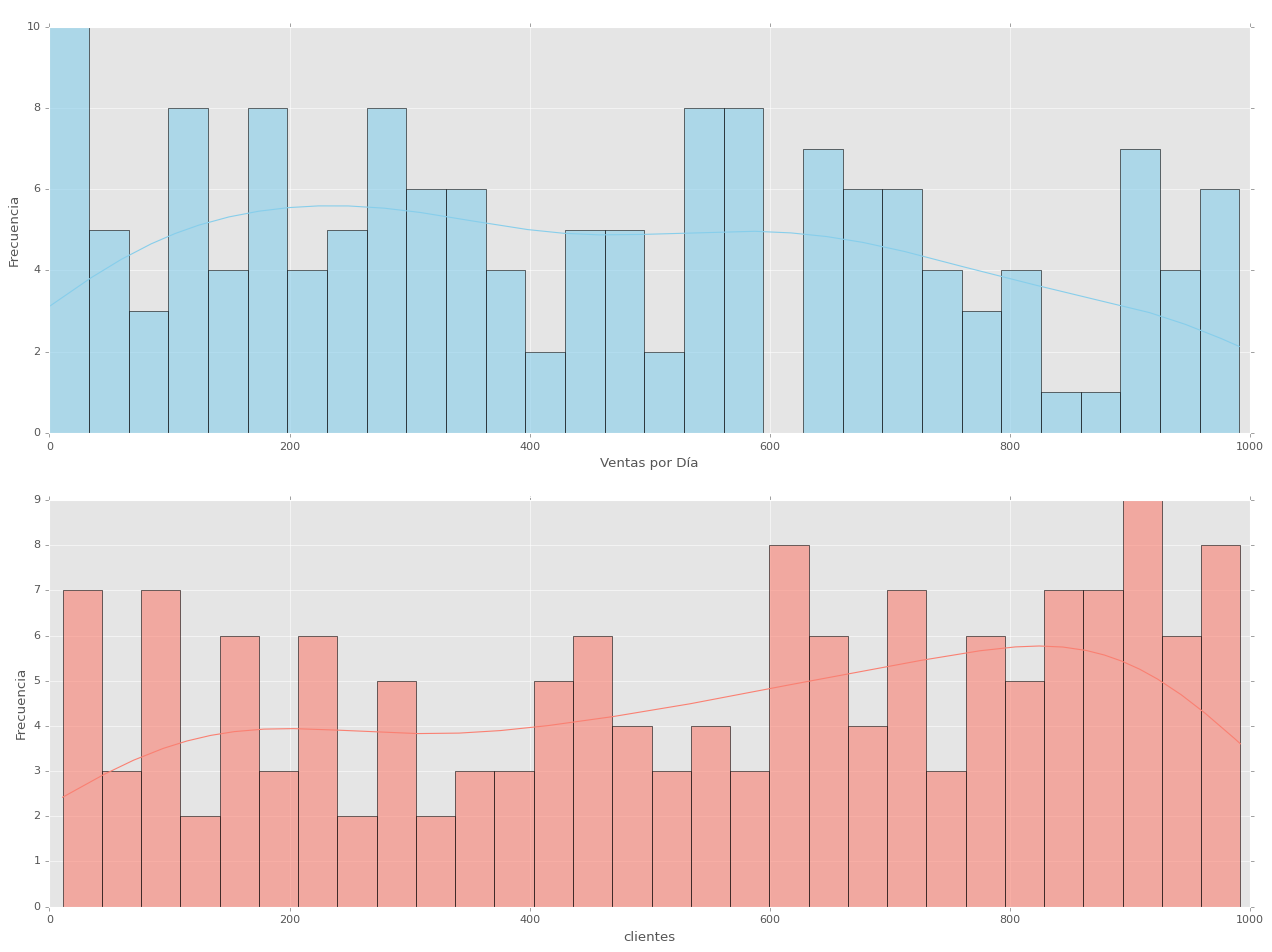

Coefficients: 
 [-0.04539942]
Independent term: 
 478.35371756999655
Mean squared error: 82635.41
Variance score: 0.00


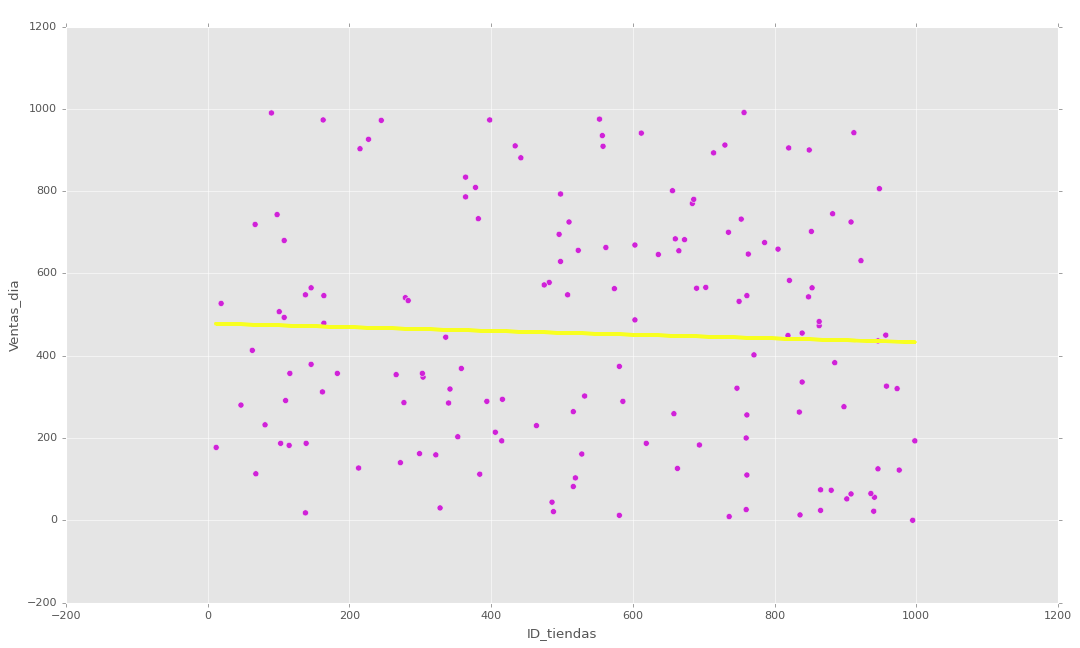

Coefficients: 
 [-0.04509587 -0.02048773]
Mean squared error: 82565.10
Variance score: 0.00


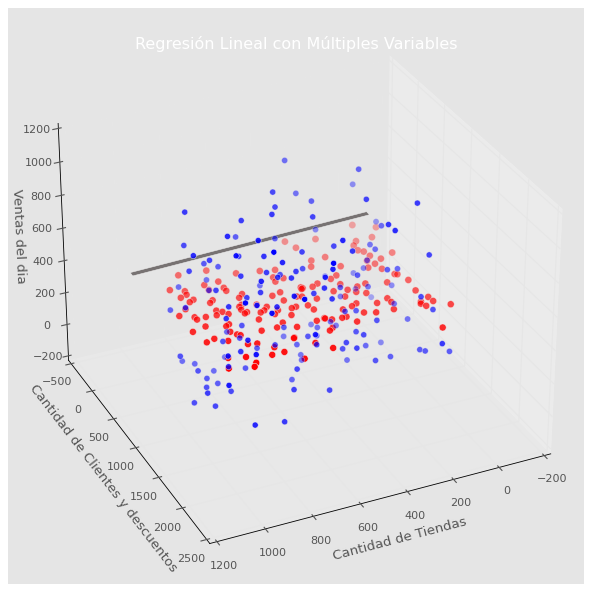

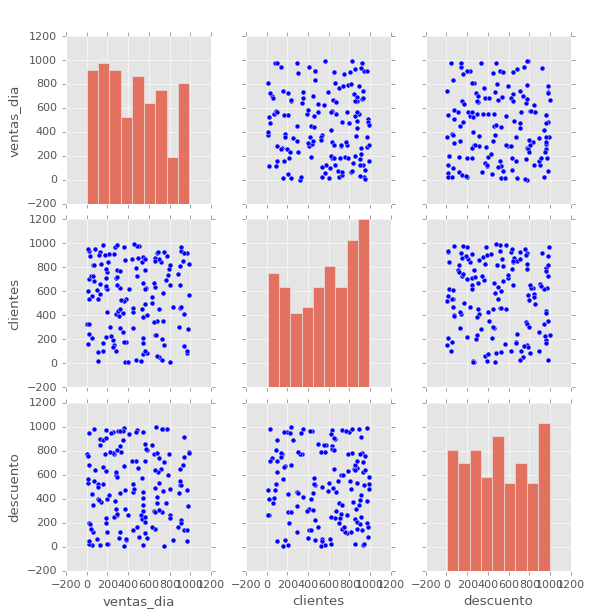

In [26]:
# Imports necesarios
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv("./0ventas_tienda.csv")

#veamos cuantas dimensiones y registros contiene el archivo
data.shape

#Veamos los primeros registros
data.head()

# Ahora veamos algunas estadísticas de nuestros datos
data.describe()

# Visualizamos rápidamente las caraterísticas de entrada
data.drop([],axis=1).hist()
plt.show()


# Histogramas llenos con sombreado usando columnas clave
import seaborn as sns

# Creamos una figura con 2 subgráficos (2 filas, 1 columna)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 12))

# Primer histograma: ventas_dia
# Este histograma permite visualizar cómo se distribuyen las ventas diarias.
# Se utiliza para identificar patrones de frecuencia, como acumulaciones, sesgos o valores atípicos.

sns.histplot(data['ventas_dia'], bins=30, kde=True, color='skyblue', alpha=0.6, edgecolor='black', ax=axes[0])
axes[0].set_title('Histograma de Ventas por Día (con sombreado)')
axes[0].set_xlabel('Ventas por Día')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True)

# Segundo histograma: clientes
# Se incluye este histograma para entender cómo se comporta la variable "clientes".
# Esto ayuda a saber si la mayoría de las tiendas reciben pocos o muchos clientes, y si hay valores extremos.

sns.histplot(data['clientes'], bins=30, kde=True, color='salmon', alpha=0.6, edgecolor='black', ax=axes[1])
axes[1].set_title('Histograma de clientes (con sombreado)')
axes[1].set_xlabel('clientes')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True)

# Ajustamos los espacios entre gráficos
plt.tight_layout()
plt.show()



#vamos a Visualizar los datos de entrada
colores=['#067173','#d022d8']
tamanios=[30,60]

f1 = data['tienda_id'].values
f2 = data['ventas_dia'].values

# Vamos a pintar en 2 colores los puntos por debajo de la media de Cantidad de Palabras
asignar=[]
for index, row in data.iterrows():
    if(row['tienda_id']>542):
        asignar.append(colores[0])
    else:
        asignar.append(colores[1])
    
# Vamos a RECORTAR los datos en la zona donde se concentran más los puntos
# esto es en el eje X: entre 0 y 3.500
# y en el eje Y: entre 0 y 80.000
filtered_data = data[(data['tienda_id'] <= 3500) & (data['ventas_dia'] <= 80000)]

f1 = filtered_data['tienda_id'].values
f2 = filtered_data['ventas_dia'].values

# Vamos a pintar en colores los puntos por debajo y por encima de la media de Cantidad de Palabras
asignar=[]
for index, row in filtered_data.iterrows():
    if(row['tienda_id']>1808):
        asignar.append(colores[0])
    else:
        asignar.append(colores[1])

# Veamos como cambian los valores una vez filtrados
filtered_data.describe()

# Asignamos nuestra variable de entrada X para entrenamiento y las etiquetas Y.
dataX =filtered_data[["tienda_id"]]
X_train = np.array(dataX)
y_train = filtered_data['ventas_dia'].values

# Creamos el objeto de Regresión Linear
regr = linear_model.LinearRegression()

# Entrenamos nuestro modelo
regr.fit(X_train, y_train)

# Hacemos las predicciones que en definitiva una línea (en este caso, al ser 2D)
y_pred = regr.predict(X_train)

# Veamos los coeficienetes obtenidos, En nuestro caso, serán la Tangente
print('Coefficients: \n', regr.coef_)
# Este es el valor donde corta el eje Y (en X=0)
print('Independent term: \n', regr.intercept_)
# Error Cuadrado Medio
print("Mean squared error: %.2f" % mean_squared_error(y_train, y_pred))
# Puntaje de Varianza. El mejor puntaje es un 1.0
print('Variance score: %.2f' % r2_score(y_train, y_pred))


# Esta gráfica permite observar la relación entre el ID de tienda y las ventas diarias.
# Se utiliza una regresión lineal simple para identificar una posible tendencia general entre ambas variables.
plt.scatter(X_train[:,0], y_train,  c=asignar, s=tamanios[0])
plt.plot(X_train[:,0], y_pred, color='#f8ff20', linewidth=3)

plt.xlabel('ID_tiendas')
plt.ylabel('Ventas_dia')
plt.title('Regresión Lineal')

plt.show()

#Vamos a intentar mejorar el Modelo, con una dimensión más 3D: 
# Este gráfico permite visualizar cómo interactúan dos variables (ID de tienda y clientes + descuento)
# para explicar las ventas diarias. El plano representa el modelo de regresión, y se evalúa cómo se ajusta a los datos reales.

suma = (filtered_data["clientes"] + filtered_data['descuento'].fillna(0))

dataX2 =  pd.DataFrame()
dataX2["tienda_id"] = filtered_data["tienda_id"]
dataX2["suma"] = suma
XY_train = np.array(dataX2)
z_train = filtered_data['ventas_dia'].values

# Creamos un nuevo objeto de Regresión Lineal
regr2 = linear_model.LinearRegression()

# Entrenamos el modelo, esta vez, con 2 dimensiones
# obtendremos 2 coeficientes, para graficar un plano
regr2.fit(XY_train, z_train)

# Hacemos la predicción con la que tendremos puntos sobre el plano hallado
z_pred = regr2.predict(XY_train)

# Los coeficientes
print('Coefficients: \n', regr2.coef_)
# Error cuadrático medio
print("Mean squared error: %.2f" % mean_squared_error(z_train, z_pred))
# Evaluamos el puntaje de varianza (siendo 1.0 el mejor posible)
print('Variance score: %.2f' % r2_score(z_train, z_pred))

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Creamos una malla, sobre la cual graficaremos el plano
xx, yy = np.meshgrid(np.linspace(0, 1050, num=10), np.linspace(0, 60, num=10))

# calculamos los valores del plano para los puntos x e y
nuevoX = (regr2.coef_[0] * xx)
nuevoY = (regr2.coef_[1] * yy) 

# calculamos los correspondientes valores para z. Debemos sumar el punto de intercepción
z = (nuevoX + nuevoY + regr2.intercept_)

# Graficamos el plano
ax.plot_surface(xx, yy, z, alpha=0.5, cmap='hot')

# Graficamos en azul los puntos en 3D
ax.scatter(XY_train[:, 0], XY_train[:, 1], z_train, c='blue',s=30)

# Graficamos en rojo, los puntos que 
ax.scatter(XY_train[:, 0], XY_train[:, 1], z_pred, c='red',s=40)

# con esto situamos la "camara" con la que visualizamos
ax.view_init(elev=30., azim=65)
        
ax.set_xlabel('Cantidad de Tiendas')
ax.set_ylabel('Cantidad de Clientes y descuentos')
ax.set_zlabel('Ventas del dia')
ax.set_title('Regresión Lineal con Múltiples Variables')


# Pairplot para análisis de correlaciones
# Se utiliza un pairplot para observar la relación entre las variables más importantes del conjunto de datos.
# Esta visualización ayuda a detectar correlaciones posibles entre ventas, cantidad de clientes y descuentos aplicados.
sns.pairplot(data[['ventas_dia', 'clientes', 'descuento']])
plt.suptitle("Relaciones entre variables", y=1.02)
plt.show()


